In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import (
    classification_report,
    f1_score, precision_score, recall_score,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')


/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU


### Load Data & Vocab

In [ ]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')
subword_dir = Path('../') 


with open(subword_dir / 'subword_bio.json') as f:
    subword_data = json.load(f) 

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    label2id      = v['label2id']
    id2label      = v['id2label']
    Entity_labels = v['Entity_labels']
    MAX_LEN_BERT  = v['MAX_LEN_BERT']

with open(split_dir / 'split_indices.json') as f:
    split = json.load(f)
idx_train          = split['idx_train']
idx_val            = split['idx_val']
idx_test           = split['idx_test']
idx_train_balanced = split['idx_train_balanced']   

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)} | Balanced: {len(idx_train_balanced)}')
print(f'Labels ({len(label2id)}): {sorted(label2id.keys())}')
print(f'MAX_LEN_BERT: {MAX_LEN_BERT}')
print(f'Subword resumes loaded: {len(subword_data)}')

Train: 154 | Val: 33 | Test: 33
Labels (22): ['<PAD_LABEL>', 'B-College Name', 'B-Companies worked at', 'B-Degree', 'B-Designation', 'B-Email Address', 'B-Graduation Year', 'B-Location', 'B-Name', 'B-Skills', 'B-Years of Experience', 'I-College Name', 'I-Companies worked at', 'I-Degree', 'I-Designation', 'I-Email Address', 'I-Graduation Year', 'I-Location', 'I-Name', 'I-Skills', 'I-Years of Experience', 'O']
MAX_LEN_BERT: 512
Subword resumes loaded: 220


### Tokenizer & Label Alignment


In [4]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)


def align_labels_chunked(tokens, tags, tokenizer, max_len, label2id, stride=128):
    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        max_length=max_len,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors=None,
    )

    all_chunks = []
    for chunk_idx in range(len(enc['input_ids'])):
        word_ids = enc.word_ids(chunk_idx)
        label_ids = []
        prev_word_idx = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word_idx:
                label_ids.append(label2id.get(tags[wid], label2id.get('O', 0)))
            else:
                label_ids.append(-100)
            prev_word_idx = wid

        all_chunks.append({
            'input_ids'      : torch.tensor(enc['input_ids'][chunk_idx],      dtype=torch.long),
            'attention_mask' : torch.tensor(enc['attention_mask'][chunk_idx], dtype=torch.long),
            'token_type_ids' : torch.tensor(enc['token_type_ids'][chunk_idx], dtype=torch.long),
            'labels'         : torch.tensor(label_ids,                        dtype=torch.long),
        })

    return all_chunks


# Quick alignment demo
demo_chunks = align_labels_chunked(
    subword_data[0]['tokens'], subword_data[0]['tags'], tokenizer, MAX_LEN_BERT, label2id
)
print(f'Resume 0 : {len(demo_chunks)} chunk(s)')
print('input_ids (first 15) :', demo_chunks[0]['input_ids'][:15].tolist())
print('labels    (first 15) :', demo_chunks[0]['labels'][:15].tolist())


Resume 0 : 1 chunk(s)
input_ids (first 15) : [101, 11113, 24158, 5369, 2243, 1046, 3270, 4646, 2458, 5482, 9669, 5397, 8191, 1001, 1001]
labels    (first 15) : [-100, 2, -100, -100, -100, 3, -100, 4, 5, 5, 6, -100, 1, 1, -100]


### Dataset & DataLoaders

In [ ]:
class NERDataset(Dataset):
    def __init__(self, indices, subword_data, tokenizer, max_len, label2id, stride=128):
        self.samples = []
        for i in indices:
            entry  = subword_data[i]
            chunks = align_labels_chunked(
                entry['tokens'], entry['tags'], tokenizer, max_len, label2id, stride
            )
            self.samples.extend(chunks)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


BATCH_SIZE = 4
ACCUMULATION_STEPS = 2

train_dataset = NERDataset(idx_train_balanced, subword_data, tokenizer, MAX_LEN_BERT, label2id)
val_dataset   = NERDataset(idx_val,   subword_data, tokenizer, MAX_LEN_BERT, label2id)
test_dataset  = NERDataset(idx_test,  subword_data, tokenizer, MAX_LEN_BERT, label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train samples (chunks): {len(train_dataset)}')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train samples (chunks): 298
Train batches: 75 | Val: 20 | Test: 18


### Model

In [6]:
model = BertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label={int(k): v for k, v in id2label.items()},
    label2id=label2id,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1797.66it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; no

Total params    : 108,908,566
Trainable params: 108,908,566


### Hyperparameters

In [7]:
NUM_EPOCHS    = 50
LR            = 2e-5
WARMUP_RATIO  = 0.1
PATIENCE      = 12      # early stopping patience (val F1)

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps : {total_steps} | Warmup steps: {warmup_steps}')

Total steps : 3750 | Warmup steps: 375


### Helper — Decode Predictions

Converts logits back to BIO tag sequences


In [8]:
def decode_preds(logits, label_ids, id2label):

    preds = logits.argmax(dim=-1).cpu().numpy()   # (batch, seq)
    refs  = label_ids.cpu().numpy()               # (batch, seq)

    y_true, y_pred = [], []
    for pred_seq, ref_seq in zip(preds, refs):
        true_row, pred_row = [], []
        for p, r in zip(pred_seq, ref_seq):
            if r == -100:
                continue
            true_row.append(id2label[r])
            pred_row.append(id2label[p])
        y_true.append(true_row)
        y_pred.append(pred_row)
    return y_true, y_pred

In [9]:
from torch import nn

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)


### Training

In [10]:
from torch.cuda.amp import autocast, GradScaler

model_save_dir = Path('./model_result')
model_save_dir.mkdir(exist_ok=True)
BEST_CKPT = model_save_dir / 'bert_best.pt'

ACCUMULATION_STEPS = 2
scaler = GradScaler()

history = []
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Training
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for i, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with autocast():
            outputs = model(**batch)
            loss = loss_fn(
                outputs.logits.view(-1, len(label2id)),
                batch['labels'].view(-1)
            ) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with autocast():
                outputs = model(**batch)
                val_loss += loss_fn(
                    outputs.logits.view(-1, len(label2id)),
                    batch['labels'].view(-1)
                ).item()
            yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
            all_true.extend(yt)
            all_pred.extend(yp)

    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_true, all_pred)

    history.append({
        'epoch'      : epoch,
        'train_loss' : avg_train_loss,
        'val_loss'   : avg_val_loss,
        'val_f1'     : val_f1,
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), BEST_CKPT)
        flag = '  <- best'
    else:
        patience_ctr += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={avg_val_loss:.4f}  '
          f'val_f1={val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (patience={PATIENCE})')
        break

print(f'\nBest val F1: {best_val_f1:.4f}')

/tmp/ipykernel_336910/257323953.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_336910/257323953.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_336910/257323953.py:38: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/tmp/ipykernel_336910/257323953.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/

Epoch  1/50  train_loss=2.7151  val_loss=2.0462  val_f1=0.0015  <- best
Epoch  2/50  train_loss=1.0772  val_loss=0.6104  val_f1=0.0000
Epoch  3/50  train_loss=0.5593  val_loss=0.4866  val_f1=0.0000
Epoch  4/50  train_loss=0.4693  val_loss=0.4207  val_f1=0.0000
Epoch  5/50  train_loss=0.3899  val_loss=0.3955  val_f1=0.0056  <- best
Epoch  6/50  train_loss=0.3172  val_loss=0.3639  val_f1=0.1302  <- best
Epoch  7/50  train_loss=0.2654  val_loss=0.3781  val_f1=0.2523  <- best
Epoch  8/50  train_loss=0.2413  val_loss=0.4137  val_f1=0.3201  <- best
Epoch  9/50  train_loss=0.1963  val_loss=0.3743  val_f1=0.3337  <- best
Epoch 10/50  train_loss=0.1622  val_loss=0.3754  val_f1=0.3979  <- best
Epoch 11/50  train_loss=0.1293  val_loss=0.3969  val_f1=0.4031  <- best
Epoch 12/50  train_loss=0.1046  val_loss=0.3913  val_f1=0.4271  <- best
Epoch 13/50  train_loss=0.0929  val_loss=0.3823  val_f1=0.4580  <- best
Epoch 14/50  train_loss=0.0773  val_loss=0.3914  val_f1=0.4646  <- best
Epoch 15/50  train_

### Training Curves

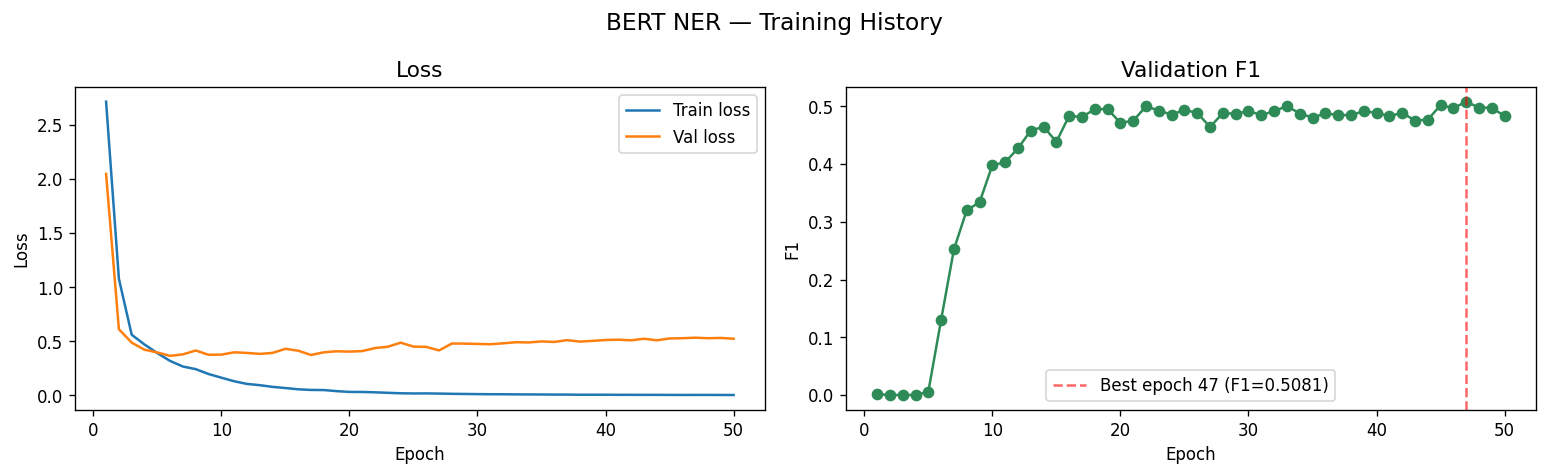

In [11]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1'], color='seagreen', marker='o')
best_ep = hist_df.loc[hist_df['val_f1'].idxmax()]
axes[1].axvline(best_ep['epoch'], linestyle='--', color='red', alpha=0.6,
                label=f"Best epoch {int(best_ep['epoch'])} (F1={best_ep['val_f1']:.4f})")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_title('Validation F1'); axes[1].legend()

plt.suptitle('BERT NER — Training History', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()

y_test_all, y_pred_all = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
        y_test_all.extend(yt)
        y_pred_all.extend(yp)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test_all, y_pred_all, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.4091    0.6585    0.5047        41
Companies worked at     0.2949    0.2584    0.2754        89
             Degree     0.4262    0.6667    0.5200        39
        Designation     0.4225    0.4615    0.4412        65
      Email Address     0.6667    0.9167    0.7719        24
    Graduation Year     0.4762    0.6667    0.5556        30
           Location     0.0000    0.0000    0.0000         5
               Name     0.8611    0.9118    0.8857        34
             Skills     0.0588    0.1667    0.0870        36
Years of Experience     0.4286    0.5000    0.4615         6

          micro avg     0.3730    0.5095    0.4307       369
          macro avg     0.4044    0.5207    0.4503       369
       weighted avg     0.4102    0.5095    0.4482       369



### Per-Entity Bar Chart

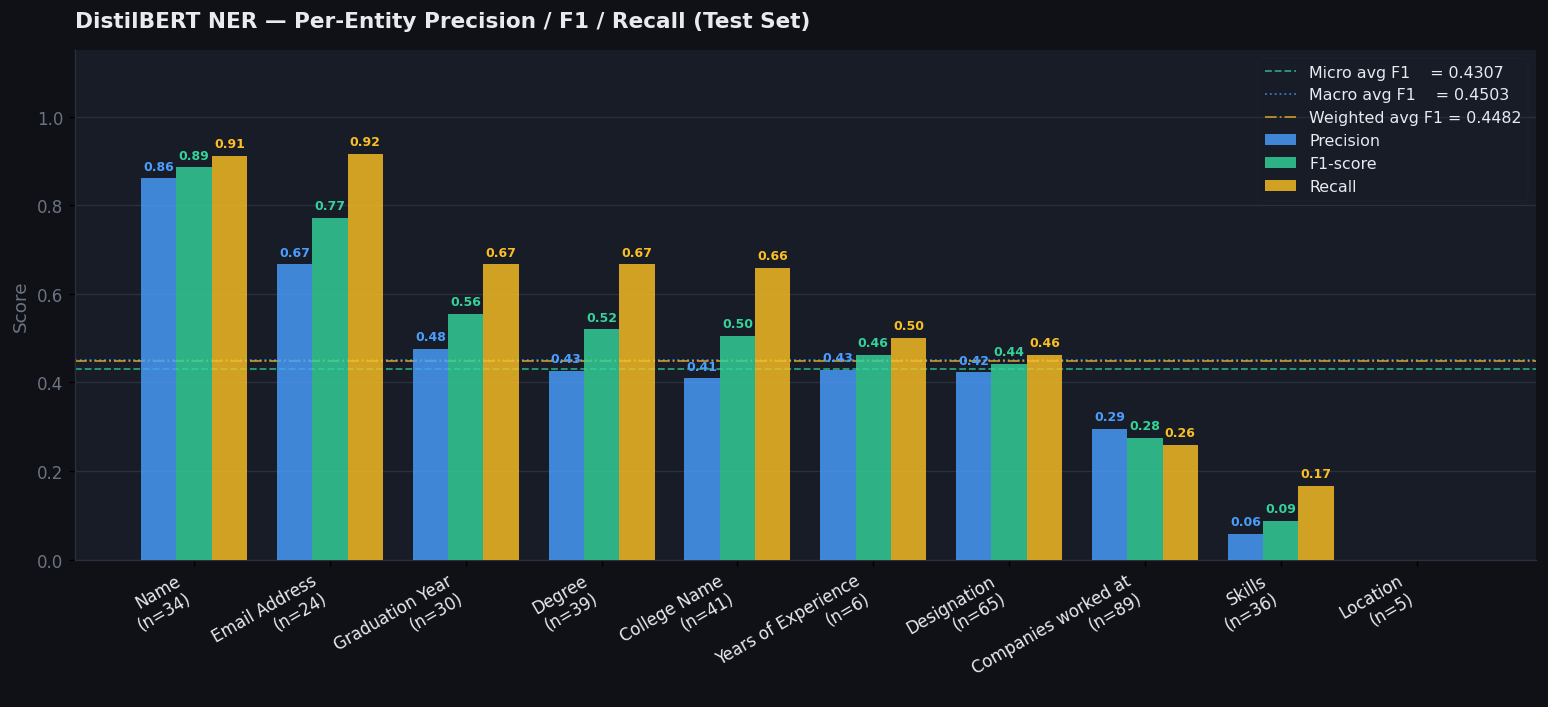

In [13]:
from seqeval.metrics import classification_report as seq_report
import numpy as np

report_dict = seq_report(y_test_all, y_pred_all, digits=4, output_dict=True)

micro_f1    = report_dict['micro avg']['f1-score']
macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict.get('weighted avg', {}).get('f1-score', 0)

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

# Sort by F1 descending
labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores_    = [per_label[k]['f1-score'] for k in labels_sorted]
precision_    = [per_label[k]['precision'] for k in labels_sorted]
recall_       = [per_label[k]['recall']    for k in labels_sorted]
support_      = [int(per_label[k]['support']) for k in labels_sorted]

n = len(labels_sorted)
x = np.arange(n)
w = 0.26

BG      = '#0f1117'
SURFACE = '#181c27'
BORDER  = '#2a2f3e'
MUTED   = '#6b7280'
TEXT    = '#e8eaf0'
COLOR_P = '#4a9eff'
COLOR_F = '#34d399'
COLOR_R = '#fbbf24'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURFACE)

bars_p = ax.bar(x - w, precision_, width=w, color=COLOR_P, alpha=0.82, label='Precision', zorder=3)
bars_f = ax.bar(x,     f1_scores_, width=w, color=COLOR_F, alpha=0.82, label='F1-score',  zorder=3)
bars_r = ax.bar(x + w, recall_,    width=w, color=COLOR_R, alpha=0.82, label='Recall',    zorder=3)

# Value labels on top of each bar
for bars, color in [(bars_p, COLOR_P), (bars_f, COLOR_F), (bars_r, COLOR_R)]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.02:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.013,
                f'{h:.2f}', ha='center', va='bottom',
                fontsize=7.5, color=color, fontweight='bold',
            )


ax.set_xticks(x)
ax.set_xticklabels(
    [f'{lbl}\n(n={s})' for lbl, s in zip(labels_sorted, support_)],
    rotation=30, ha='right', fontsize=10, color=TEXT,
)

# Reference lines
ax.axhline(micro_f1,    color=COLOR_F, linestyle='--', linewidth=1.1, alpha=0.7,
           label=f'Micro avg F1    = {micro_f1:.4f}', zorder=2)
ax.axhline(macro_f1,    color=COLOR_P, linestyle=':',  linewidth=1.1, alpha=0.7,
           label=f'Macro avg F1    = {macro_f1:.4f}', zorder=2)
ax.axhline(weighted_f1, color=COLOR_R, linestyle='-.', linewidth=1.1, alpha=0.7,
           label=f'Weighted avg F1 = {weighted_f1:.4f}', zorder=2)

ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0, 1.1, 0.2)], fontsize=10, color=MUTED)
ax.set_ylabel('Score', color=MUTED, fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(BORDER)
ax.tick_params(which='both')
ax.yaxis.grid(True, color=BORDER, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    'DistilBERT NER — Per-Entity Precision / F1 / Recall (Test Set)',
    color=TEXT, fontsize=13, fontweight='bold', pad=14, loc='left',
)
ax.legend(
    loc='upper right', framealpha=0.15,
    facecolor=SURFACE, edgecolor=BORDER,
    labelcolor=TEXT, fontsize=9.5,
)

plt.tight_layout()
plt.show()

### Inference Demo

In [14]:
import re

def predict_resume(text: str) -> list:
    words = text.split()
    enc = tokenizer(
        words,
        is_split_into_words=True,
        max_length=MAX_LEN_BERT,
        truncation=True,
        stride=128,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors='pt',
    )

    all_results = {}
    for chunk_idx in range(len(enc['input_ids'])):
        chunk_input = {
            'input_ids'      : enc['input_ids'][chunk_idx].unsqueeze(0).to(DEVICE),
            'attention_mask' : enc['attention_mask'][chunk_idx].unsqueeze(0).to(DEVICE),
        }
        word_ids = enc.word_ids(chunk_idx)
        model.eval()
        with torch.no_grad():
            logits = model(**chunk_input).logits[0]
        pred_ids = logits.argmax(dim=-1).cpu().tolist()

        for wid, pid in zip(word_ids, pred_ids):
            if wid is None or wid in all_results:
                continue
            all_results[wid] = id2label[pid]  

    return [(words[wid], tag) for wid, tag in sorted(all_results.items())]


def extract_entities(predictions):
    """Group BIO-tagged tokens into entity strings by label."""
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


sample_tokens = subword_data[idx_test[0]]['tokens']
sample_text   = ' '.join(sample_tokens)
preds    = predict_resume(sample_text)
entities = extract_entities(preds)

print('Extracted Entities (Test Resume 0)')
for lbl, values in entities.items():
    print(f'[{lbl}]')
    for v in values:
        print(f'  • {v[:70]}')
    print()

Extracted Entities (Test Resume 0)
[Name]
  • dushyant bhatt

[Email Address]
  • indeed ##com/r/dushyant bhatt/140749dace5dc26f

[Designation]
  • software engineer

[Companies worked at]
  • microsoft

[College Name]
  • saurashtra university

[Graduation Year]
  • 2007

[Skills]
  • problem



### Save Model & Results

In [15]:
# Save tokenizer + model config alongside weights
tokenizer.save_pretrained(model_save_dir / 'bert_ner')
model.config.save_pretrained(model_save_dir / 'bert_ner')

# Save results in the same schema as results_crf.pkl
results = {
    'model'          : 'BERT',
    'best_epoch'     : int(hist_df.loc[hist_df['val_f1'].idxmax(), 'epoch']),
    'val_f1'         : best_val_f1,
    'test_f1'        : f1_score(y_test_all, y_pred_all),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(y_test_all, y_pred_all),
    'test_recall'    : recall_score(y_test_all, y_pred_all),
    'y_test'         : y_test_all,
    'y_pred'         : y_pred_all,
    'idx_test'       : idx_test,
    'history'        : history,
}

with open(model_save_dir / 'results_bert.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Model  saved -> model_result/bert_best.pt')
print('Config saved -> model_result/bert_ner/')
print('Results saved -> model_result/results_bert.pkl')
print()
print('Final BERT Scores')
print(f"Val  F1       : {results['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Test Micro F1 : {results['test_f1_micro']:.4f}")
print(f"Test Macro F1 : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model  saved -> model_result/bert_best.pt
Config saved -> model_result/bert_ner/
Results saved -> model_result/results_bert.pkl

Final BERT Scores
Val  F1       : 0.5081
Test F1       : 0.4307
Test Micro F1 : 0.4307
Test Macro F1 : 0.4503
Test Precision: 0.3730
Test Recall   : 0.5095
